In [28]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [29]:
X_train=np.linspace(-1,1,21)

In [30]:
Y_train=np.array([-0.6561,-0.4096,-0.216,-0.125,-0.064,-0.027,-0.0081,0,0.0016,0.0001,0,0.0001,0.0016,0,0.0081,0.027,0.064,0.125,0.216,0.4096,0.6561])

In [31]:
X_test=np.linspace(-1,1,21)

In [32]:
Y_test=Y_train + np.random.normal(0, 0.1, len(Y_train))

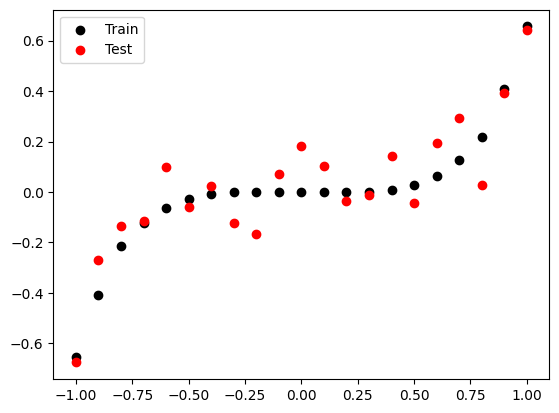

In [33]:
plt.scatter(X_train,Y_train,c='black',label='Train')
plt.scatter(X_test,Y_test,c='red',label='Test')
plt.legend()
plt.show()

In [34]:
model= Sequential()
model.add(Dense(128,input_dim=1,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation="linear"))

adam=Adam(learning_rate=0.1)
model.compile(optimizer=adam,loss='mse',metrics=['mse'])
history=model.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=500,verbose=False)

In [35]:
# evaluate the model
_,Train_mse=model.evaluate(X_train,Y_train,verbose=0)
_,Test_mse=model.evaluate(X_test,Y_test,verbose=0)
print('Train: {} , Test : {}'.format(Train_mse,Test_mse))


Train: 0.002179238013923168 , Test : 0.018151484429836273


In [36]:
Y_pred=model.predict(X_test)

1/1 [==============================] - 0s 38ms/step


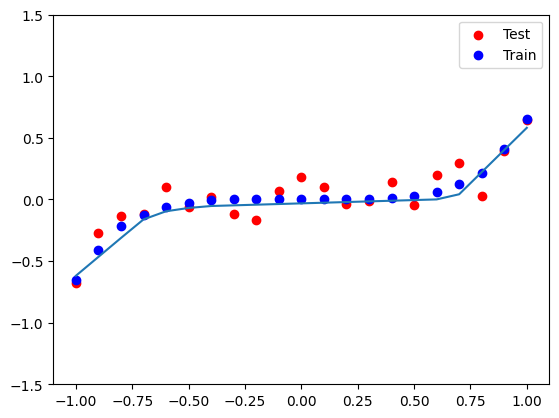

In [37]:
plt.figure()
plt.scatter(X_test,Y_test,c='red',label='Test')
plt.scatter(X_test,Y_train,c='blue',label='Train')
plt.plot(X_test,Y_pred)
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

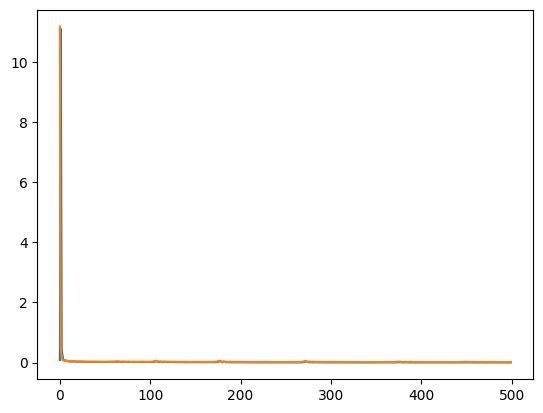

In [38]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Dropout Model

In [39]:
model1=Sequential()
model1.add(Dense(128,input_dim=1,activation='relu'))
model1.add(Dropout(0.2))
model1.add(Dense(128,activation='relu'))
model1.add(Dropout(0.2))            
model1.add(Dense(1,activation="linear"))
adam=Adam(learning_rate=0.1)
model1.compile(optimizer=adam ,loss='mse',metrics=['mse'])

history=model1.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=500,verbose=False)

In [40]:
# evaluate the model1
_,Train_mse=model1.evaluate(X_train,Y_train,verbose=0)
_,Test_mse=model1.evaluate(X_test,Y_test,verbose=0)
print('Train: {} , Test : {}'.format(Train_mse,Test_mse))


Train: 0.029818546026945114 , Test : 0.037564486265182495


In [41]:
Y_pred=model.predict(X_test)


1/1 [==============================] - 0s 21ms/step


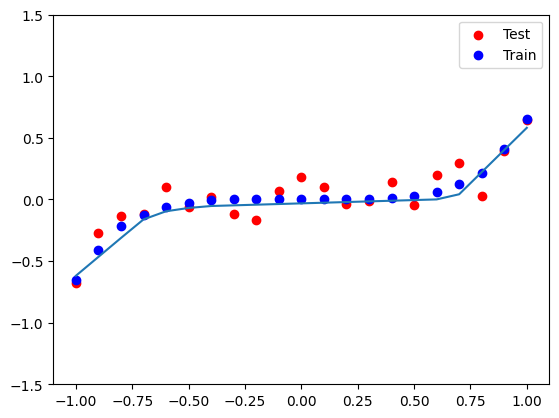

In [42]:
plt.figure()
plt.scatter(X_test,Y_test,c='red',label='Test')
plt.scatter(X_test,Y_train,c='blue',label='Train')
plt.plot(X_test,Y_pred)
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

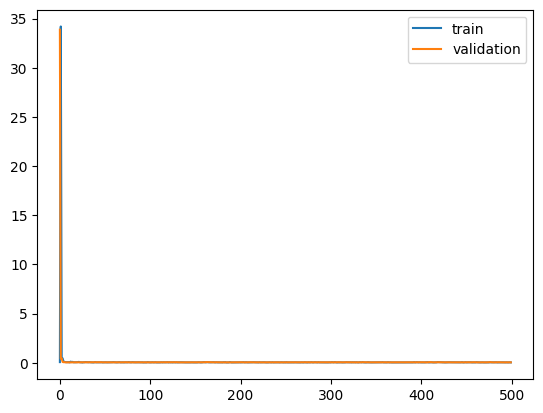

In [43]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])